<a href="https://colab.research.google.com/github/aniray2908/nlp-llm-journey/blob/main/01_nlp_fundamentals/demos/01_tokenisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cell 1 — Imports & Install**

In [1]:
!pip install tiktoken -q

import tiktoken
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

**Cell 2 — Load Encoders**

In [2]:
# GPT-4's tokeniser
enc_gpt4 = tiktoken.get_encoding("cl100k_base")

# GPT-2's tokeniser
enc_gpt2 = tiktoken.get_encoding("gpt2")

print(f"GPT-4 vocab size: {enc_gpt4.n_vocab:,}")   # 100,277
print(f"GPT-2 vocab size: {enc_gpt2.n_vocab:,}")   # 50,257

GPT-4 vocab size: 100,277
GPT-2 vocab size: 50,257


**Cell 3 — Basic Encode & Decode**

In [3]:
text = "Hello, how are you doing today?"

ids    = enc_gpt4.encode(text)
tokens = [enc_gpt4.decode([i]) for i in ids]

print(f"Text:   {text}")
print(f"IDs:    {ids}")
print(f"Tokens: {tokens}")
print(f"Length: {len(ids)} tokens")

Text:   Hello, how are you doing today?
IDs:    [9906, 11, 1268, 527, 499, 3815, 3432, 30]
Tokens: ['Hello', ',', ' how', ' are', ' you', ' doing', ' today', '?']
Length: 8 tokens


**Cell 4 — Visualise Tokens with Colour Coding**

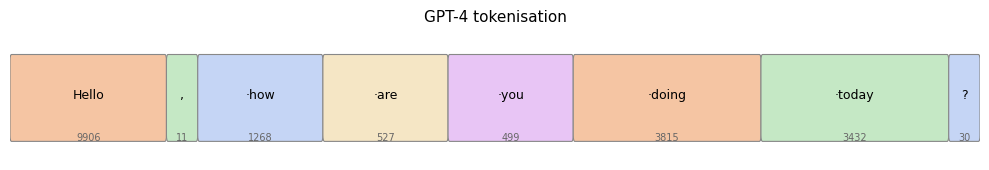

  8 tokens | 31 chars | ratio: 3.9 chars/token


In [4]:
def visualise_tokens(text, encoder, title="Token boundaries"):
    ids    = encoder.encode(text)
    tokens = [encoder.decode([i]) for i in ids]

    colours = ['#f5c5a3', '#c5e8c5', '#c5d5f5', '#f5e6c5', '#e8c5f5']
    fig, ax = plt.subplots(figsize=(max(10, len(text) * 0.18), 1.8))
    ax.set_xlim(0, len(text))
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, fontsize=11, pad=10)

    x = 0
    for i, token in enumerate(tokens):
        w = len(token)
        ax.add_patch(mpatches.FancyBboxPatch(
            (x + 0.05, 0.2), w - 0.1, 0.6,
            boxstyle="round,pad=0.05",
            facecolor=colours[i % len(colours)],
            edgecolor='#888', linewidth=0.8
        ))
        ax.text(x + w/2, 0.52, token.replace(' ', '·'),
                ha='center', va='center', fontsize=9, fontweight='500')
        ax.text(x + w/2, 0.18, str(ids[i]),
                ha='center', va='center', fontsize=7, color='#666')
        x += w

    plt.tight_layout()
    plt.show()
    print(f"  {len(ids)} tokens | {len(text)} chars | ratio: {len(text)/len(ids):.1f} chars/token")

# Try it
visualise_tokens("Hello, how are you doing today?", enc_gpt4, "GPT-4 tokenisation")

**Cell 5 — Word vs Subword vs Character Comparison**

In [5]:
def word_tokenise(text):
    import re
    return re.findall(r"\w+|[^\w\s]", text)

def char_tokenise(text):
    return list(text)

text = "The transformer architecture revolutionised natural language processing."

word_tokens = word_tokenise(text)
char_tokens = char_tokenise(text)
bpe_tokens  = [enc_gpt4.decode([i]) for i in enc_gpt4.encode(text)]

print(f"{'Method':<12} {'Tokens':>8}  Example")
print("-" * 60)
print(f"{'Word':<12} {len(word_tokens):>8}  {word_tokens[:6]}...")
print(f"{'Character':<12} {len(char_tokens):>8}  {char_tokens[:6]}...")
print(f"{'BPE (GPT4)':<12} {len(bpe_tokens):>8}  {bpe_tokens[:6]}...")

Method         Tokens  Example
------------------------------------------------------------
Word                8  ['The', 'transformer', 'architecture', 'revolutionised', 'natural', 'language']...
Character          72  ['T', 'h', 'e', ' ', 't', 'r']...
BPE (GPT4)          9  ['The', ' transformer', ' architecture', ' revolution', 'ised', ' natural']...


**Cell 6 — OOV Behaviour**

In [6]:
oov_words = [
    "ChatGPT",
    "transformers",
    "unhappiness",
    "tokenization",
    "blockchain",
    "AAABBBCCC",   # completely made up
    "😊🔥💡",       # emoji
]

print(f"{'Word':<20} {'Tokens':<8} {'Split'}")
print("-" * 60)
for word in oov_words:
    ids    = enc_gpt4.encode(word)
    tokens = [enc_gpt4.decode([i]) for i in ids]
    print(f"{word:<20} {len(ids):<8} {tokens}")

Word                 Tokens   Split
------------------------------------------------------------
ChatGPT              3        ['Chat', 'G', 'PT']
transformers         2        ['transform', 'ers']
unhappiness          3        ['un', 'h', 'appiness']
tokenization         2        ['token', 'ization']
blockchain           2        ['block', 'chain']
AAABBBCCC            4        ['AA', 'AB', 'BB', 'CCC']
😊🔥💡                  7        ['�', '�', '�', '�', '�', '�', '�']


**Cell 7 — Tokenisation Quirks**

In [7]:
# Quirk 1: spaces change the token
print("=== Spaces matter ===")
for text in ["Token", " Token", "  Token"]:
    ids = enc_gpt4.encode(text)
    print(f"  '{text}' → {ids} ({len(ids)} token{'s' if len(ids)>1 else ''})")

# Quirk 2: case changes the token
print("\n=== Case matters ===")
for text in ["hello", "Hello", "HELLO"]:
    ids = enc_gpt4.encode(text)
    print(f"  '{text}' → {ids}")

# Quirk 3: numbers are unpredictable
print("\n=== Numbers ===")
for text in ["1", "10", "100", "1000", "10000", "1234567890"]:
    ids = enc_gpt4.encode(text)
    print(f"  '{text}' → {len(ids)} token(s): {ids}")

# Quirk 4: arithmetic insight
print("\n=== Why LLMs struggle with maths ===")
expr = "1234 + 5678 = 6912"
ids    = enc_gpt4.encode(expr)
tokens = [enc_gpt4.decode([i]) for i in ids]
print(f"  '{expr}'")
print(f"  Tokens: {tokens}")

=== Spaces matter ===
  'Token' → [3404] (1 token)
  ' Token' → [9857] (1 token)
  '  Token' → [220, 9857] (2 tokens)

=== Case matters ===
  'hello' → [15339]
  'Hello' → [9906]
  'HELLO' → [51812, 1623]

=== Numbers ===
  '1' → 1 token(s): [16]
  '10' → 1 token(s): [605]
  '100' → 1 token(s): [1041]
  '1000' → 2 token(s): [1041, 15]
  '10000' → 2 token(s): [1041, 410]
  '1234567890' → 4 token(s): [4513, 10961, 16474, 15]

=== Why LLMs struggle with maths ===
  '1234 + 5678 = 6912'
  Tokens: ['123', '4', ' +', ' ', '567', '8', ' =', ' ', '691', '2']


**Cell 8 — GPT-2 vs GPT-4 Tokeniser Comparison**

In [8]:
texts = [
    "Hello world",
    "The quick brown fox jumps over the lazy dog",
    "def forward(self, x): return self.linear(x)",
    "불고기 먹고 싶다",          # Korean
    "Je ne sais pas",            # French
]

print(f"{'Text':<45} {'GPT-2':>6} {'GPT-4':>6}")
print("-" * 60)
for text in texts:
    n2 = len(enc_gpt2.encode(text))
    n4 = len(enc_gpt4.encode(text))
    print(f"{text[:44]:<45} {n2:>6} {n4:>6}")

print("\nLower token count = more efficient vocabulary")

Text                                           GPT-2  GPT-4
------------------------------------------------------------
Hello world                                        2      2
The quick brown fox jumps over the lazy dog        9      9
def forward(self, x): return self.linear(x)       14     11
불고기 먹고 싶다                                         20     11
Je ne sais pas                                     5      4

Lower token count = more efficient vocabulary


**Cell 9 — Token Frequency Distribution**

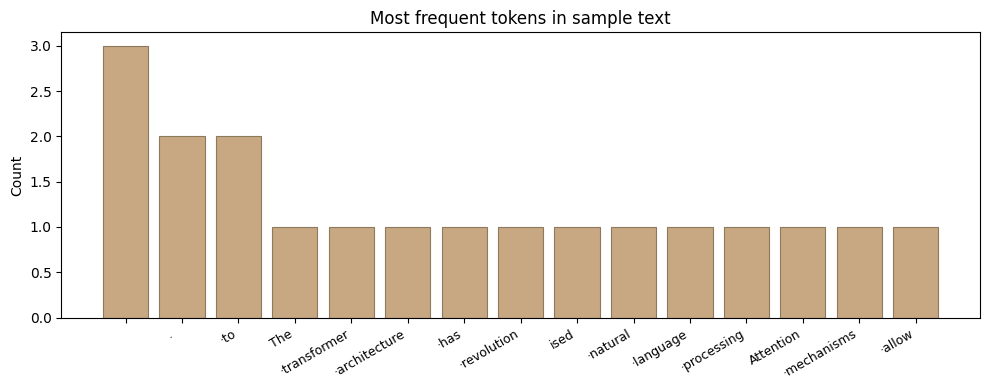


Total tokens: 48
Unique tokens: 44


In [9]:
sample_text = """
The transformer architecture has revolutionised natural language processing.
Attention mechanisms allow models to weigh the importance of different tokens
when generating each output. Pre-training on large corpora enables transfer
learning to downstream tasks with minimal fine-tuning required.
"""

ids    = enc_gpt4.encode(sample_text)
tokens = [enc_gpt4.decode([i]) for i in ids]

# Count frequencies
freq = Counter(tokens).most_common(15)
words, counts = zip(*freq)

plt.figure(figsize=(10, 4))
bars = plt.bar(range(len(words)), counts,
               color='#c8a882', edgecolor='#8c7a5e', linewidth=0.8)
plt.xticks(range(len(words)), [w.replace(' ', '·') for w in words],
           rotation=30, ha='right', fontsize=9)
plt.title("Most frequent tokens in sample text")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"\nTotal tokens: {len(ids)}")
print(f"Unique tokens: {len(set(ids))}")

**Cell 10 — Build a Tiny Character-level Tokeniser from Scratch**

In [10]:
class CharTokeniser:
    def __init__(self, text):
        # Build vocabulary from unique characters in text
        self.chars   = sorted(set(text))
        self.stoi    = {c: i for i, c in enumerate(self.chars)}  # char → id
        self.itos    = {i: c for i, c in enumerate(self.chars)}  # id → char
        self.vocab_size = len(self.chars)

    def encode(self, text):
        return [self.stoi[c] for c in text]

    def decode(self, ids):
        return ''.join([self.itos[i] for i in ids])


# Train it on a small corpus
corpus = """To be or not to be that is the question
Whether tis nobler in the mind to suffer"""

tokeniser = CharTokeniser(corpus)
print(f"Vocabulary ({tokeniser.vocab_size} chars): {''.join(tokeniser.chars)}")

# Encode and decode
text    = "To be or not"
encoded = tokeniser.encode(text)
decoded = tokeniser.decode(encoded)

print(f"\nOriginal: '{text}'")
print(f"Encoded:  {encoded}")
print(f"Decoded:  '{decoded}'")
print(f"Round-trip success: {text == decoded}")

Vocabulary (20 chars): 
 TWabdefhilmnoqrstu

Original: 'To be or not'
Encoded:  [2, 14, 1, 5, 7, 1, 14, 16, 1, 13, 14, 18]
Decoded:  'To be or not'
Round-trip success: True


**Cell 11 — Putting It Together: Tokens → Model Input Shape**

In [11]:
# Simulate preparing a batch of text for a Transformer
import torch

sentences = [
    "The cat sat on the mat",
    "Transformers changed NLP forever",
    "Tokenisation is step zero",
]

# Encode each sentence
encoded = [enc_gpt4.encode(s) for s in sentences]
lengths = [len(e) for e in encoded]

print("Encoded sequences:")
for s, e in zip(sentences, encoded):
    print(f"  '{s}'")
    print(f"   → {e}  ({len(e)} tokens)\n")

# In real training, sequences in a batch must be same length
# so we pad shorter ones to match the longest
max_len    = max(lengths)
pad_token  = 0   # using 0 as a stand-in pad token id

padded = [e + [pad_token] * (max_len - len(e)) for e in encoded]
tensor = torch.tensor(padded)

print(f"Padded batch tensor shape: {tensor.shape}")
print(f"  → (batch_size={tensor.shape[0]}, seq_len={tensor.shape[1]})")
print(f"\nThis tensor is the direct input to nn.Embedding in a Transformer")

Encoded sequences:
  'The cat sat on the mat'
   → [791, 8415, 7731, 389, 279, 5634]  (6 tokens)

  'Transformers changed NLP forever'
   → [9140, 388, 5614, 452, 12852, 16058]  (6 tokens)

  'Tokenisation is step zero'
   → [3404, 8082, 374, 3094, 7315]  (5 tokens)

Padded batch tensor shape: torch.Size([3, 6])
  → (batch_size=3, seq_len=6)

This tensor is the direct input to nn.Embedding in a Transformer
